Please upload your image:


Saving image (3).jpg to image (3).jpg


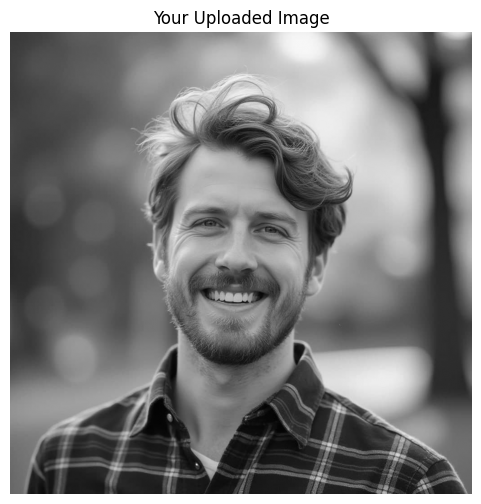

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Prompt to upload a file from your computer
print("Please upload your image:")
uploaded = files.upload()

# 2. Automatically get the name of the file you just uploaded
filename = next(iter(uploaded))

# 3. Read the image and convert it to grayscale
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# 4. Show the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Your Uploaded Image')
plt.axis('off')
plt.show()

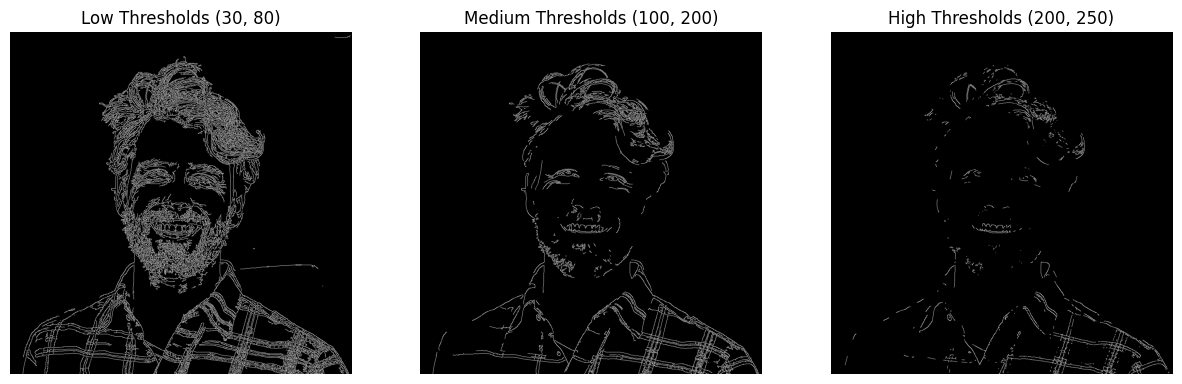

In [16]:
# Apply Canny with different thresholds to YOUR image
canny_low = cv2.Canny(image, 30, 80)      # Lets lots of details and noise in
canny_mid = cv2.Canny(image, 100, 200)    # Good balance
canny_high = cv2.Canny(image, 200, 250)   # Only the sharpest edges survive

# Plotting the results side-by-side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(canny_low, cmap='gray')
plt.title('Low Thresholds (30, 80)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(canny_mid, cmap='gray')
plt.title('Medium Thresholds (100, 200)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(canny_high, cmap='gray')
plt.title('High Thresholds (200, 250)')
plt.axis('off')

plt.show()

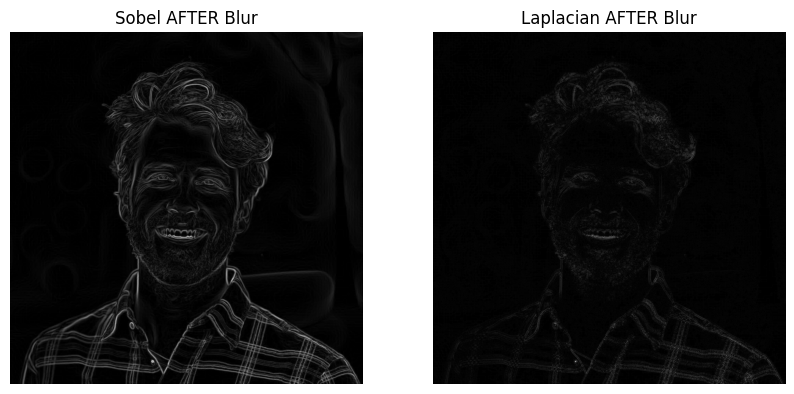

In [17]:
# 1. Apply Gaussian Blur to smooth YOUR image
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

# 2. Apply Sobel to the BLURRED image
sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_blurred = np.sqrt(sobel_x**2 + sobel_y**2)

# 3. Apply Laplacian to the BLURRED image
laplacian_blurred = cv2.Laplacian(blurred_image, cv2.CV_64F)

# Plotting the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sobel_blurred, cmap='gray')
plt.title('Sobel AFTER Blur')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.abs(laplacian_blurred), cmap='gray')
plt.title('Laplacian AFTER Blur')
plt.axis('off')

plt.show()

Please upload your image:


Saving medical.jpg to medical.jpg


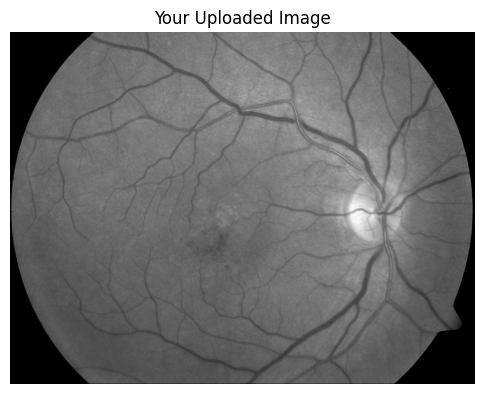

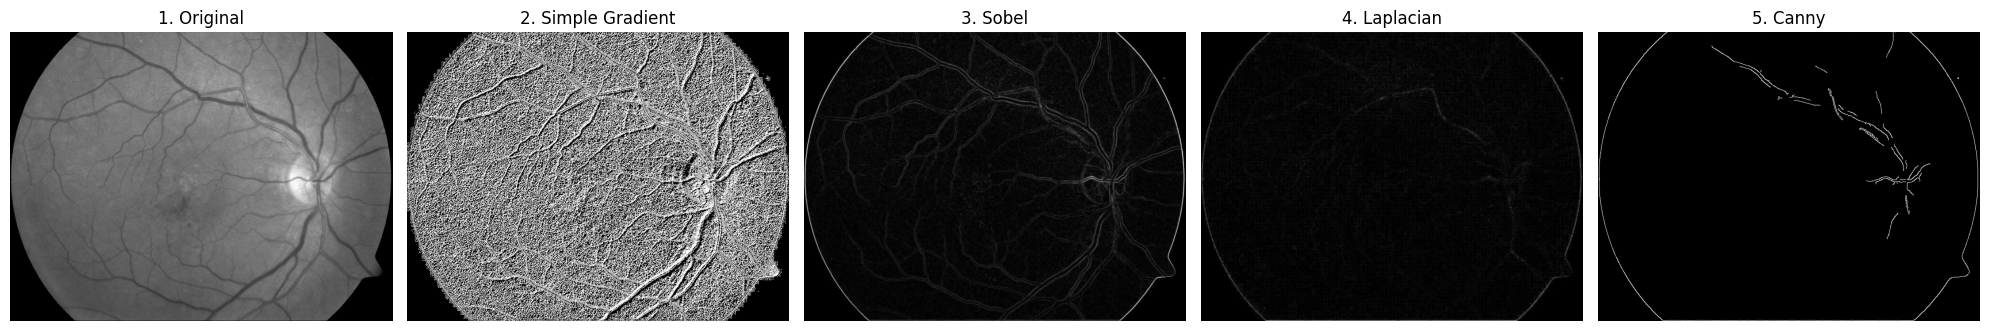

In [19]:
# 1. Prompt to upload a file from your computer
print("Please upload your image:")
uploaded = files.upload()

# 2. Automatically get the name of the file you just uploaded
filename = next(iter(uploaded))

# 3. Read the image and convert it to grayscale
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# 4. Show the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Your Uploaded Image')
plt.axis('off')
plt.show()

# Calculate Simple Gradient
gx = np.zeros_like(image, dtype=np.float64)
gy = np.zeros_like(image, dtype=np.float64)
gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)
simple_gradient = np.sqrt(gx**2 + gy**2)

# Calculate Standard Sobel (Without Blur)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
standard_sobel = np.sqrt(sobel_x**2 + sobel_y**2)

# Calculate Standard Laplacian (Without Blur)
standard_laplacian = cv2.Laplacian(image, cv2.CV_64F)

# Calculate Standard Canny
standard_canny = cv2.Canny(image, 100, 200)

# Compare all methods on YOUR image side-by-side
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(image, cmap='gray')
plt.title('1. Original')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(simple_gradient, cmap='gray')
plt.title('2. Simple Gradient')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(standard_sobel, cmap='gray')
plt.title('3. Sobel')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(np.abs(standard_laplacian), cmap='gray')
plt.title('4. Laplacian')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(standard_canny, cmap='gray')
plt.title('5. Canny')
plt.axis('off')

plt.tight_layout()
plt.show()